In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32


In [ ]:
train_data = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_data.flow_from_directory(
       '/content/drive/MyDrive/archive/Training',
       target_size=(IMG_SIZE, IMG_SIZE),
       batch_size=BATCH_SIZE,
       class_mode='binary' )



Found 2940 images belonging to 2 classes.


In [ ]:
val_generator = train_data.flow_from_directory(
    '/content/drive/MyDrive/archive/Testing',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary' )

Found 705 images belonging to 2 classes.


In [ ]:
model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(128, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(128, activation='relu'),
layers.Dense(1, activation='sigmoid') ])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(train_generator, epochs=5, validation_data=val_generator, batch_size= BATCH_SIZE)


Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 53s 550ms/step - accuracy: 0.9803 - loss: 0.0606 - val_accuracy: 0.9887 - val_loss: 0.0257
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 139ms/step - accuracy: 0.9895 - loss: 0.0262 - val_accuracy: 0.9858 - val_loss: 0.0450
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 138ms/step - accuracy: 0.9956 - loss: 0.0196 - val_accuracy: 0.9986 - val_loss: 0.0070
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 141ms/step - accuracy: 0.9986 - loss: 0.0056 - val_accuracy: 0.9957 - val_loss: 0.0110
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 138ms/step - accuracy: 0.9976 - loss: 0.0065 - val_accuracy: 0.9943 - val_loss: 0.0172


In [ ]:
model.save('/content/drive/MyDrive/archive/ Braintumor.h5')


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
model = load_model('/content/drive/MyDrive/archive/ BrainTumor.h5')
print("Model Loaded")

Model Loaded


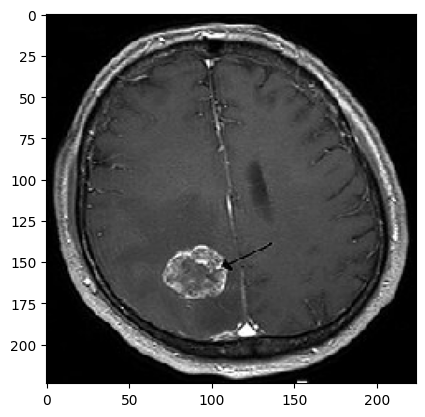

In [ ]:
test_image_path="/content/drive/MyDrive/tumor.jpg"
img=image.load_img(test_image_path,target_size=(224,224))
plt.imshow(img)
plt.axis()
plt.show()

In [ ]:
img_array=image.img_to_array(img)
img_array=np.expand_dims(img_array,axis=0)
img_array /= 255.

In [ ]:
#Predict
prediction = model.predict(img_array)
print(train_generator.class_indices)

if prediction[0][0] > 0.5:
    predicted_class = 1
else:
    predicted_class = 0

print("Predicted class index:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
{'No Tumor': 0, 'Yes Tumor': 1}
Predicted class index: 0
